Mounted at /content/drive
Loading dataset from: /content/drive/MyDrive/MBP_PREDICTOR/data/features_cleaned_final.csv
Dataset shape: (3072, 1057)
Features: 1055
Target distribution: {0: 1539, 1: 1533}
Test set: (615, 1055)

LOADING LIGHTGBM MODEL
Available LightGBM models: ['LightGBM_92.pkl', 'LightGBM_91.22.pkl']
Loaded: LightGBM_92.pkl

MODEL PERFORMANCE EVALUATION
Test Accuracy: 0.9203 (92.03%)
Test AUC-ROC: 0.9796

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       308
           1       0.90      0.94      0.92       307

    accuracy                           0.92       615
   macro avg       0.92      0.92      0.92       615
weighted avg       0.92      0.92      0.92       615


ROC-AUC CURVE VISUALIZATION


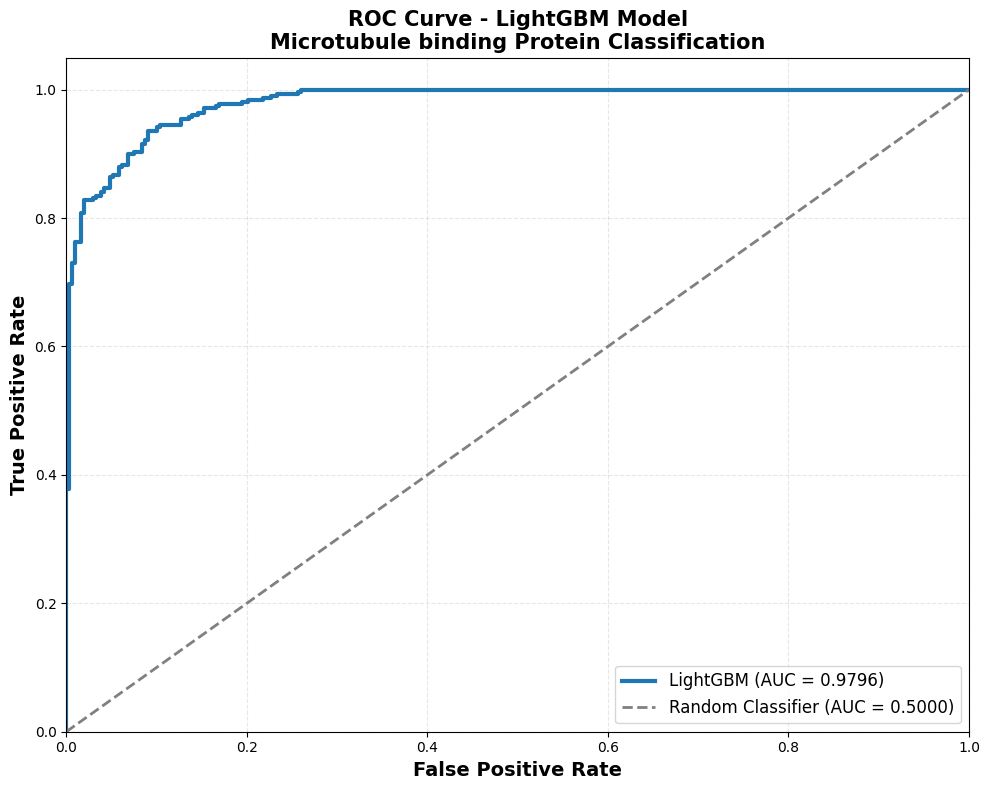

ROC-AUC Score: 0.9796
Optimal Classification Threshold: 0.6277
At this threshold: TPR=0.9349, FPR=0.0909

FEATURE IMPORTANCE ANALYSIS
Top 30 Most Important Features:
 1. AAC_Y                                         --> 255.000000
 2. AAC_F                                         --> 239.000000
 3. Hydro_mean                                    --> 205.000000
 4. AAC_C                                         --> 193.000000
 5. AAC_K                                         --> 188.000000
 6. AAC_G                                         --> 158.000000
 7. AAC_L                                         --> 143.000000
 8. AAC_E                                         --> 133.000000
 9. AAC_W                                         --> 128.000000
10. AAC_P                                         --> 118.000000
11. E_377                                         --> 117.000000
12. E_69                                          --> 108.000000
13. E_647                                         --> 

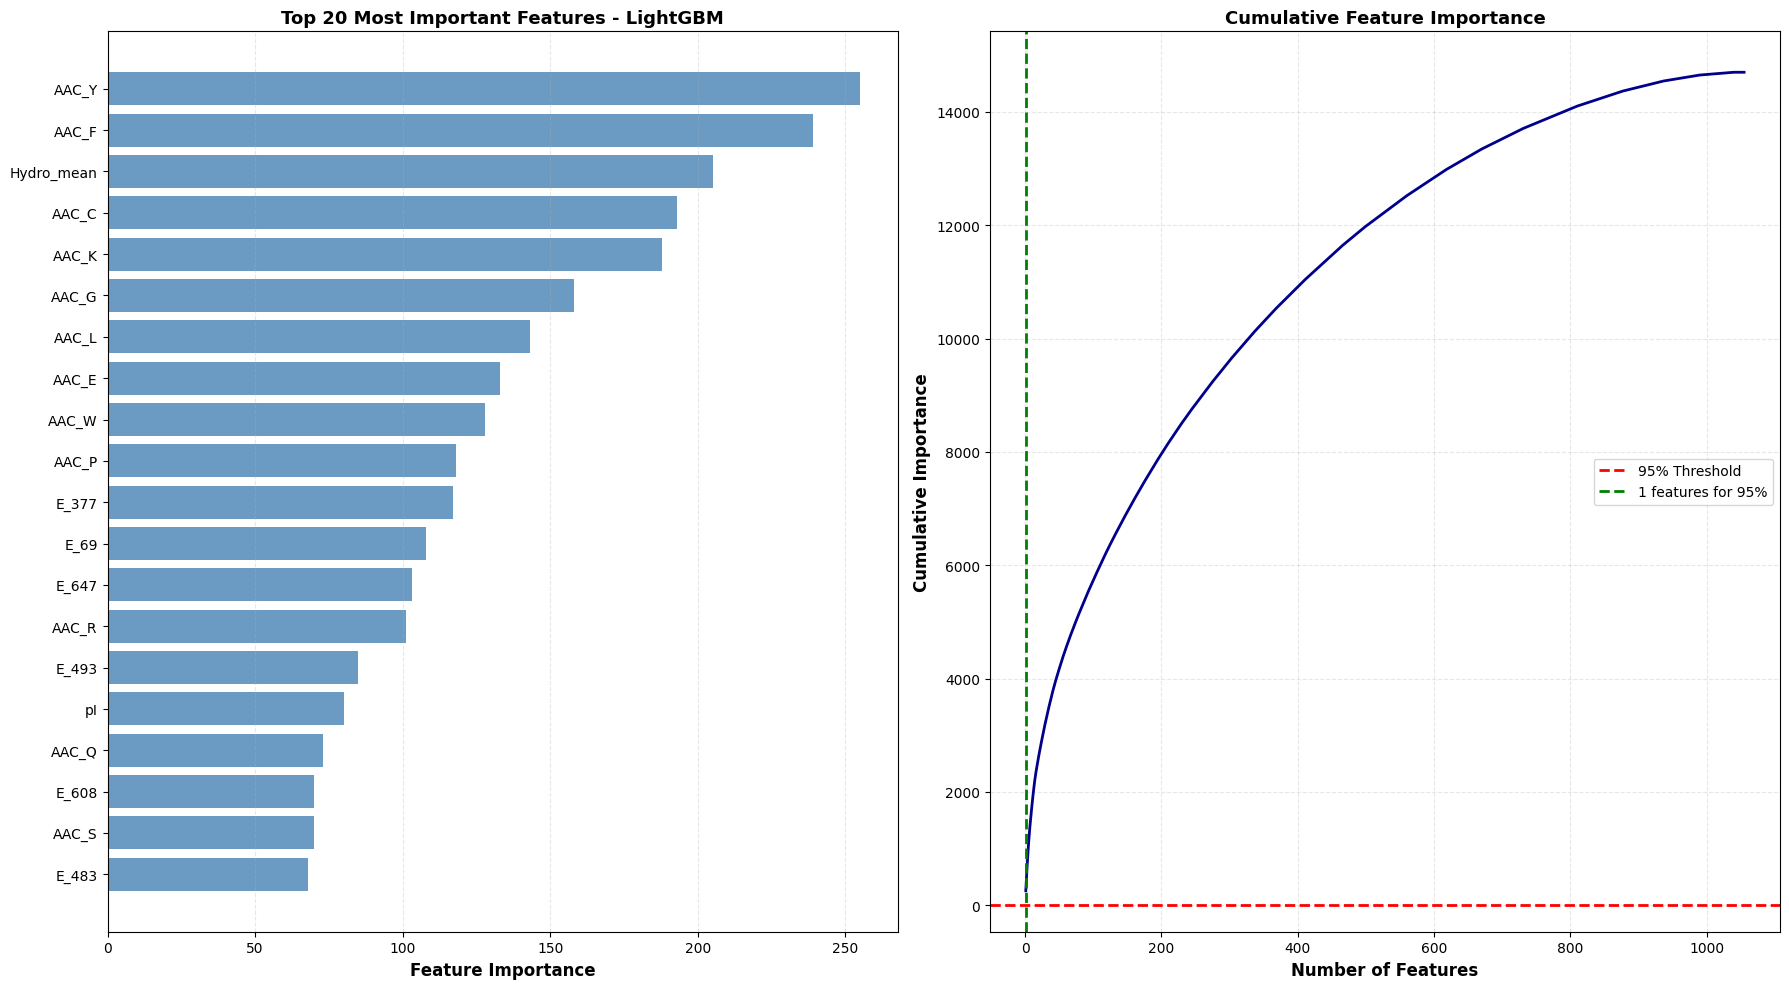


Number of features needed for 95% cumulative importance: 1

FEATURE TYPE DISTRIBUTION IN TOP 20
Feature type breakdown in top 20:
  AAC (Amino Acid Composition)       : 12 features (60.0%)
  Embeddings (ProtBERT)              :  6 features (30.0%)
  Physicochemical Properties         :  2 features (10.0%)


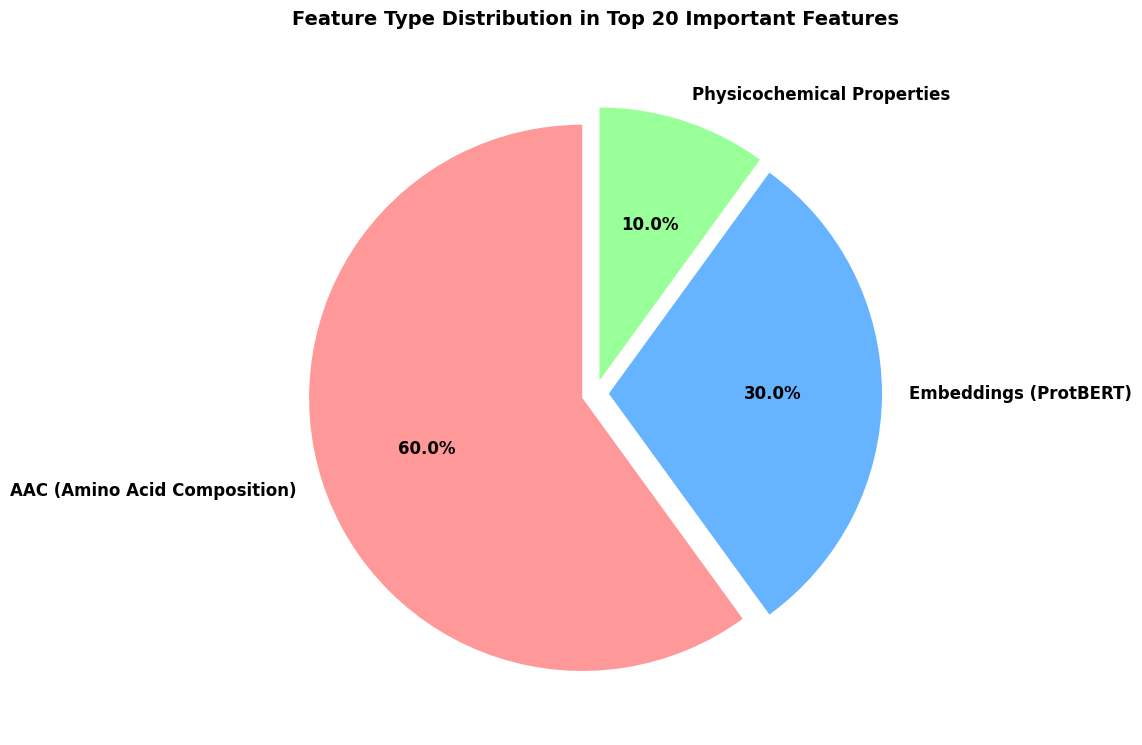


DETAILED ANALYSIS BY FEATURE CATEGORY

Top AAC Features:
  Rank  1: AAC_Y                (Amino Acid: Y) --> 255.000000
  Rank  2: AAC_F                (Amino Acid: F) --> 239.000000
  Rank  4: AAC_C                (Amino Acid: C) --> 193.000000
  Rank  5: AAC_K                (Amino Acid: K) --> 188.000000
  Rank  6: AAC_G                (Amino Acid: G) --> 158.000000
  Rank  7: AAC_L                (Amino Acid: L) --> 143.000000
  Rank  8: AAC_E                (Amino Acid: E) --> 133.000000
  Rank  9: AAC_W                (Amino Acid: W) --> 128.000000
  Rank 10: AAC_P                (Amino Acid: P) --> 118.000000
  Rank 14: AAC_R                (Amino Acid: R) --> 101.000000

Top Embedding Features: (13 in top 30)
  Rank 11: E_377                --> 117.000000
  Rank 12: E_69                 --> 108.000000
  Rank 13: E_647                --> 103.000000
  Rank 15: E_493                --> 85.000000
  Rank 18: E_608                --> 70.000000

Top Physicochemical Features:
  Rank  

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, classification_report

drive.mount('/content/drive')

# ============================================================
# 1. Setup Paths and Load Dataset
# ============================================================
BASE_PATH = "/content/drive/MyDrive/MBP_PREDICTOR"
DATA_PATH = os.path.join(BASE_PATH, "data/features_cleaned_final.csv")
MODEL_DIR = os.path.join(BASE_PATH, "TRAINED_MODELS")

print(f"Loading dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")

# Prepare features and target
target_col = "Label"
feature_cols = [col for col in df.columns if col not in [target_col, 'Protein_ID']]

# Sanitize feature names
def sanitize_feature_name(name):
    return name.replace('[', '_').replace(']', '_').replace('<', '_').replace('>', '_')

feature_mapping = {col: sanitize_feature_name(col) for col in feature_cols}
df_clean = df.rename(columns=feature_mapping)
feature_cols_clean = [feature_mapping[col] for col in feature_cols]

X = df_clean[feature_cols_clean]
y = df_clean[target_col]

print(f"Features: {len(feature_cols_clean)}")
print(f"Target distribution: {y.value_counts().to_dict()}")

# Recreate the same train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Test set: {X_test.shape}")

# ============================================================
# 2. Load LightGBM Model
# ============================================================
print("\n" + "="*60)
print("LOADING LIGHTGBM MODEL")
print("="*60)

# List available model files
model_files = [f for f in os.listdir(MODEL_DIR) if f.endswith('.pkl') and 'LightGBM' in f]
print(f"Available LightGBM models: {model_files}")

if not model_files:
    print("ERROR: No LightGBM model found!")
    print("Please ensure the model is saved in TRAINED_MODELS directory")
else:
    model_file = model_files[0]
    model_path = os.path.join(MODEL_DIR, model_file)
    lightgbm_model = joblib.load(model_path)
    print(f"Loaded: {model_file}")

# ============================================================
# 3. Model Performance Evaluation
# ============================================================
print("\n" + "="*60)
print("MODEL PERFORMANCE EVALUATION")
print("="*60)

# Get predictions
y_pred = lightgbm_model.predict(X_test)
y_pred_proba = lightgbm_model.predict_proba(X_test)[:, 1]

# Calculate metrics
test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test AUC-ROC: {test_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================================
# 4. ROC-AUC Curve Visualization
# ============================================================
print("\n" + "="*60)
print("ROC-AUC CURVE VISUALIZATION")
print("="*60)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_value = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='#1f77b4', lw=3,
         label=f'LightGBM (AUC = {roc_auc_value:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--',
         label='Random Classifier (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curve - LightGBM Model\nMicrotubule binding Protein Classification',
          fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc_value:.4f}")

# Find optimal threshold (Youden's J statistic)
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Classification Threshold: {optimal_threshold:.4f}")
print(f"At this threshold: TPR={tpr[optimal_idx]:.4f}, FPR={fpr[optimal_idx]:.4f}")

# ============================================================
# 5. Feature Importance Analysis
# ============================================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importances
importances = lightgbm_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Print top 30 features
print("Top 30 Most Important Features:")
for i, idx in enumerate(indices[:30], 1):
    feature_name = feature_cols_clean[idx]
    importance = importances[idx]
    print(f"{i:2d}. {feature_name:45s} --> {importance:.6f}")

# ============================================================
# 6. Feature Importance Visualization
# ============================================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE VISUALIZATION")
print("="*60)

# Top 20 features - Horizontal bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

# Left plot: Top 20 features
top_20_indices = indices[:20]
ax1.barh(range(20), importances[top_20_indices][::-1], color='steelblue', alpha=0.8)
ax1.set_yticks(range(20))
ax1.set_yticklabels([feature_cols_clean[i] for i in top_20_indices[::-1]], fontsize=10)
ax1.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax1.set_title('Top 20 Most Important Features - LightGBM', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Right plot: Cumulative importance
cumsum_importance = np.cumsum(sorted(importances, reverse=True))
ax2.plot(range(1, len(cumsum_importance)+1), cumsum_importance,
         color='darkblue', linewidth=2)
ax2.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% Threshold')
ax2.set_xlabel('Number of Features', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Importance', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3, linestyle='--')
ax2.legend(fontsize=10)

# Find number of features for 95% importance
n_features_95 = np.argmax(cumsum_importance >= 0.95) + 1
ax2.axvline(x=n_features_95, color='green', linestyle='--', linewidth=2,
            label=f'{n_features_95} features for 95%')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nNumber of features needed for 95% cumulative importance: {n_features_95}")

# ============================================================
# 7. Feature Type Distribution
# ============================================================
print("\n" + "="*60)
print("FEATURE TYPE DISTRIBUTION IN TOP 20")
print("="*60)

feature_types = {
    'AAC (Amino Acid Composition)': 0,
    'Embeddings (ProtBERT)': 0,
    'Physicochemical Properties': 0,
    'Other': 0
}

top_20_features = [feature_cols_clean[i] for i in indices[:20]]

for feature in top_20_features:
    if feature.startswith('AAC_'):
        feature_types['AAC (Amino Acid Composition)'] += 1
    elif feature.startswith('E_'):
        feature_types['Embeddings (ProtBERT)'] += 1
    elif any(x in feature for x in ['Charge', 'Hydro', 'pI', 'Motif', 'CTDC', 'CTDT', 'CTDD',
                                    'Polarity', 'Flexibility', 'Helix', 'Sheet', 'Coil']):
        feature_types['Physicochemical Properties'] += 1
    else:
        feature_types['Other'] += 1

print("Feature type breakdown in top 20:")
for ftype, count in feature_types.items():
    if count > 0:
        percentage = (count / 20) * 100
        print(f"  {ftype:35s}: {count:2d} features ({percentage:.1f}%)")

# Pie chart
fig, ax = plt.subplots(figsize=(10, 8))
non_zero_types = {k: v for k, v in feature_types.items() if v > 0}
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
explode = [0.05] * len(non_zero_types)

ax.pie(non_zero_types.values(), labels=non_zero_types.keys(), autopct='%1.1f%%',
       startangle=90, colors=colors[:len(non_zero_types)], explode=explode,
       textprops={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title('Feature Type Distribution in Top 20 Important Features',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ============================================================
# 8. Detailed Feature Analysis by Category
# ============================================================
print("\n" + "="*60)
print("DETAILED ANALYSIS BY FEATURE CATEGORY")
print("="*60)

# Group top features by type
aac_features = []
embedding_features = []
physicochemical_features = []

for i, idx in enumerate(indices[:30], 1):
    feature = feature_cols_clean[idx]
    importance = importances[idx]

    if feature.startswith('AAC_'):
        aac_features.append((i, feature, importance))
    elif feature.startswith('E_'):
        embedding_features.append((i, feature, importance))
    elif any(x in feature for x in ['Charge', 'Hydro', 'pI', 'Motif', 'CTDC', 'CTDT', 'CTDD',
                                    'Polarity', 'Flexibility', 'Helix', 'Sheet', 'Coil']):
        physicochemical_features.append((i, feature, importance))

if aac_features:
    print("\nTop AAC Features:")
    for rank, feature, importance in aac_features[:10]:
        amino_acid = feature.split('_')[1]
        print(f"  Rank {rank:2d}: {feature:20s} (Amino Acid: {amino_acid}) --> {importance:.6f}")

if embedding_features:
    print(f"\nTop Embedding Features: ({len(embedding_features)} in top 30)")
    for rank, feature, importance in embedding_features[:5]:
        print(f"  Rank {rank:2d}: {feature:20s} --> {importance:.6f}")

if physicochemical_features:
    print("\nTop Physicochemical Features:")
    for rank, feature, importance in physicochemical_features:
        print(f"  Rank {rank:2d}: {feature:35s} --> {importance:.6f}")

# ============================================================
# 9. Final Summary
# ============================================================
print("\n" + "="*60)
print("FINAL ANALYSIS SUMMARY")
print("="*60)

print(f"\nLightGBM Model Performance:")
print(f"  Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Test AUC-ROC:   {test_auc:.4f}")

print(f"\nKey Insights:")
print(f"  - {n_features_95} features capture 95% of predictive power")
print(f"  - Top feature type: {max(feature_types, key=feature_types.get)}")
print(f"  - Optimal classification threshold: {optimal_threshold:.4f}")

print(f"\nBiological Interpretation:")
if aac_features:
    top_amino_acids = [f.split('_')[1] for _, f, _ in aac_features[:3]]
    print(f"  - Most predictive amino acids: {', '.join(top_amino_acids)}")
if any('Charge' in f for _, f, _ in physicochemical_features):
    print(f"  - Charge properties are important for membrane binding")
if any('Hydro' in f for _, f, _ in physicochemical_features):
    print(f"  - Hydrophobicity plays a key role")

print("\nAnalysis complete!")